# Session 2-A — Autoencoder 기반 터보팬 이상 탐지 실습 노트북

## NASA C-MAPSS 데이터 기반 정상 학습 → 재구성 오차로 이상 탐지

**데이터**: `h2_data_copy/CMaps/` 내 FD001 (단일 운영조건, HPC degradation)  
**센서**: 21개 중 유효 14개 (상수 7개 제외)  
**방법**: 정상 구간(RUL > 125) 데이터로 Autoencoder 학습 → 재구성 오차로 고장 임박 탐지

> 참고 교재: *Hands-On Unsupervised Learning Using Python* (Ankur A. Patel)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.12.0+cpu


## 1. 데이터 로드 및 전처리

In [2]:
DATA_DIR = 'h2_data_copy/CMaps/'
cols = ['unit', 'cycle'] + [f'op_{i}' for i in range(1,4)] + [f'sensor_{i}' for i in range(1,22)]

# FD001 로드
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_FD001.txt'), sep=' ', header=None)
train_df.dropna(axis=1, how='all', inplace=True)
train_df.columns = cols

test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_FD001.txt'), sep=' ', header=None)
test_df.dropna(axis=1, how='all', inplace=True)
test_df.columns = cols

rul_df = pd.read_csv(os.path.join(DATA_DIR, 'RUL_FD001.txt'), sep=' ', header=None)
rul_df.dropna(axis=1, how='all', inplace=True)
rul_df.columns = ['rul']

print(f'Train: {train_df.shape}, Test: {test_df.shape}, RUL: {rul_df.shape}')
print(f'Train engines: {train_df.unit.nunique()}, Test engines: {test_df.unit.nunique()}')

# RUL 라벨 생성
max_cycles = train_df.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']
train_df = train_df.merge(max_cycles, on='unit')
train_df['rul'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis=1, inplace=True)

print(f'\nRUL distribution:')
print(train_df['rul'].describe())

Train: (4163, 26), Test: (2663, 26), RUL: (100, 1)
Train engines: 100, Test engines: 100

RUL distribution:
count    4163.000000
mean      106.743935
std        69.457099
min         0.000000
25%        50.000000
50%       100.000000
75%       155.000000
max       360.000000
Name: rul, dtype: float64


In [3]:
# 상수 센서 제거
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
stds = train_df[sensor_cols].std()
constant_sensors = stds[stds < 0.01].index.tolist()
useful_sensors = [s for s in sensor_cols if s not in constant_sensors]

print(f'Constant sensors ({len(constant_sensors)}): {constant_sensors}')
print(f'Useful sensors ({len(useful_sensors)}): {useful_sensors}')

# 센서-RUL 상관관계
corrs = train_df[useful_sensors + ['rul']].corr()['rul'].drop('rul').sort_values()
print(f'\nSensor-RUL Correlation:')
print(corrs.to_string())

Constant sensors (7): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Useful sensors (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Sensor-RUL Correlation:
sensor_11   -0.702130
sensor_4    -0.677097
sensor_15   -0.641410
sensor_17   -0.612514
sensor_2    -0.594216
sensor_3    -0.563945
sensor_8    -0.563839
sensor_13   -0.561403
sensor_9    -0.390488
sensor_14   -0.305517
sensor_20    0.622736
sensor_21    0.643193
sensor_7     0.654672
sensor_12    0.669134


## 2. 노화 패턴 시각화

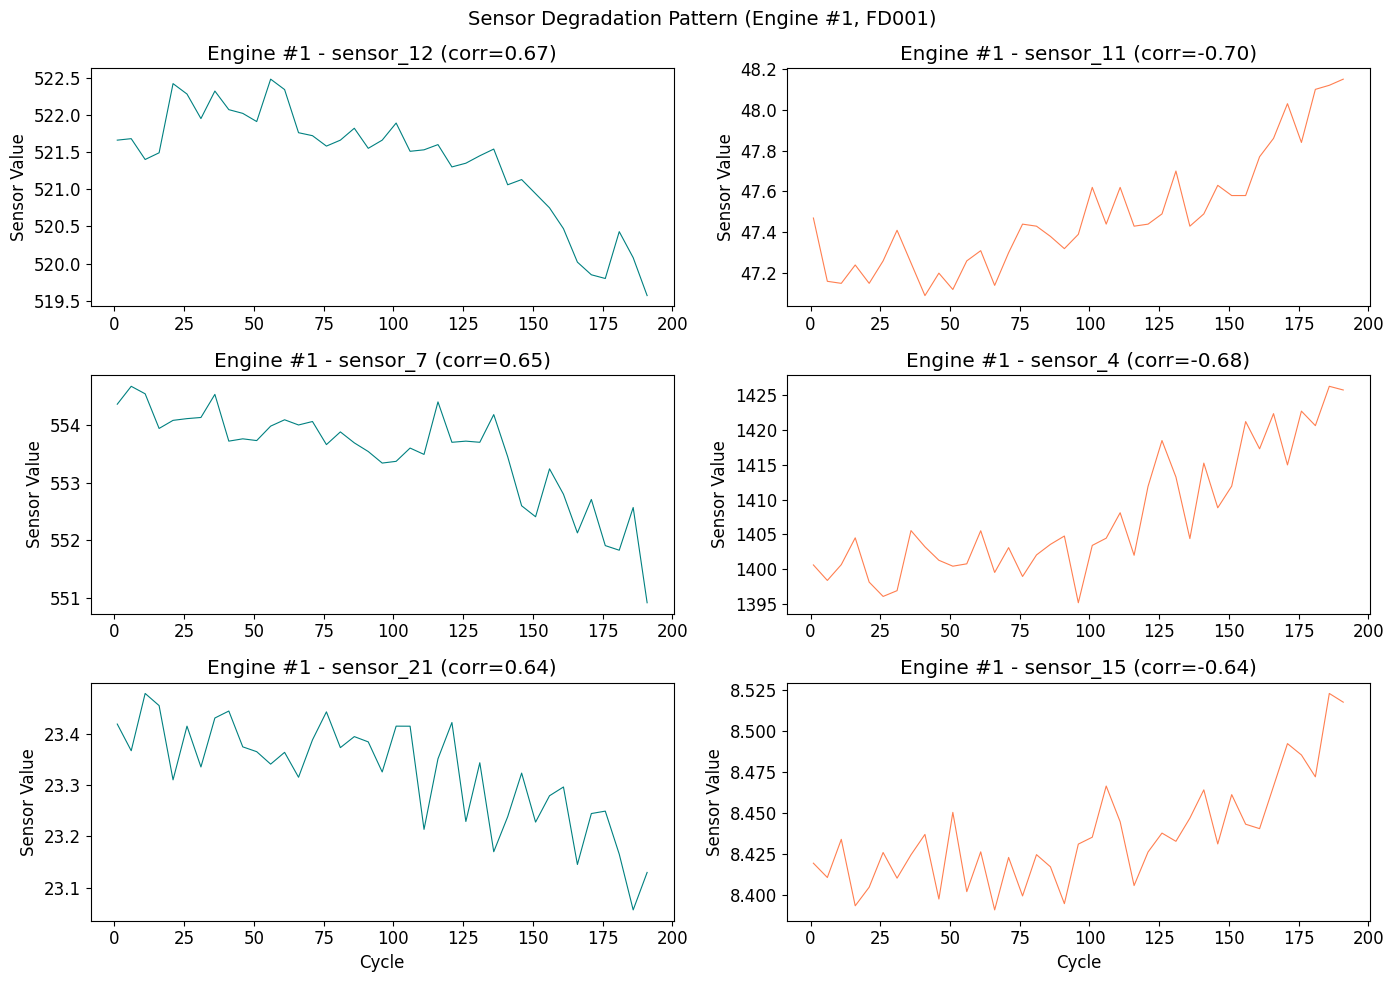


[관찰] RUL이 감소할수록(고장에 가까워질수록) 센서 값이 체계적으로 변화
[관찰] 양의 상관 센서는 정상일 때 높다가 감소, 음의 상관 센서는 반대


In [4]:
# Engine #1 노화 패턴
engine1 = train_df[train_df.unit == 1].copy()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
top_pos = ['sensor_12', 'sensor_7', 'sensor_21']  # 양의 상관
top_neg = ['sensor_11', 'sensor_4', 'sensor_15']  # 음의 상관

for i, (pos, neg) in enumerate(zip(top_pos, top_neg)):
    axes[i][0].plot(engine1['cycle'], engine1[pos], linewidth=0.8, color='teal')
    axes[i][0].set_title(f'Engine #1 - {pos} (corr={corrs[pos]:.2f})')
    axes[i][0].set_ylabel('Sensor Value')
    
    axes[i][1].plot(engine1['cycle'], engine1[neg], linewidth=0.8, color='coral')
    axes[i][1].set_title(f'Engine #1 - {neg} (corr={corrs[neg]:.2f})')
    axes[i][1].set_ylabel('Sensor Value')

axes[-1][0].set_xlabel('Cycle')
axes[-1][1].set_xlabel('Cycle')
plt.suptitle('Sensor Degradation Pattern (Engine #1, FD001)', fontsize=14)
plt.tight_layout()
plt.savefig('h2_fig_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] RUL이 감소할수록(고장에 가까워질수록) 센서 값이 체계적으로 변화")
print("[관찰] 양의 상관 센서는 정상일 때 높다가 감소, 음의 상관 센서는 반대")

## 3. 정상/이상 데이터 분리 및 정규화

In [5]:
# RUL 클리핑
train_df['rul_clip'] = train_df['rul'].clip(upper=125)

# 정상(healthy): RUL > 125, 이상(degrading): RUL <= 125
train_df['is_healthy'] = (train_df['rul'] > 125).astype(int)

print(f"Healthy (RUL>125): {train_df['is_healthy'].sum():,} ({train_df['is_healthy'].mean()*100:.1f}%)")
print(f"Degrading (RUL<=125): {(1-train_df['is_healthy']).sum():,} ({(1-train_df['is_healthy']).mean()*100:.1f}%)")

# 정상 데이터로만 스케일러 피팅
scaler = MinMaxScaler()
healthy_data = train_df[train_df['is_healthy'] == 1][useful_sensors]
scaler.fit(healthy_data)

# 전체 데이터 변환
X_all = scaler.transform(train_df[useful_sensors])
y_all = train_df['is_healthy'].values

print(f'\nFeature matrix: {X_all.shape}')
print(f'Scaled range: [{X_all.min():.3f}, {X_all.max():.3f}]')

Healthy (RUL>125): 1,563 (37.5%)
Degrading (RUL<=125): 2,600 (62.5%)

Feature matrix: (4163, 14)
Scaled range: [-0.510, 4.576]


## 4. Autoencoder 모델 정의

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

input_dim = len(useful_sensors)
model = Autoencoder(input_dim, latent_dim=8).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=14, bias=True)
  )
)

Total parameters: 2,294


## 5. 학습

In [7]:
# 정상 데이터만 학습
X_healthy = X_all[y_all == 1]
X_train_h, X_val_h = train_test_split(X_healthy, test_size=0.1, random_state=42)

train_dataset = TensorDataset(torch.FloatTensor(X_train_h))
val_dataset = TensorDataset(torch.FloatTensor(X_val_h))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        recon = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(X_train_h))
    
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon = model(batch)
            val_loss += criterion(recon, batch).item() * len(batch)
        val_losses.append(val_loss / len(X_val_h))
    
    scheduler.step(val_losses[-1])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}')

print(f'\nFinal train loss: {train_losses[-1]:.6f}')
print(f'Final val loss: {val_losses[-1]:.6f}')

Epoch  10 | Train Loss: 0.026957 | Val Loss: 0.026423


Epoch  20 | Train Loss: 0.012961 | Val Loss: 0.012236


Epoch  30 | Train Loss: 0.011500 | Val Loss: 0.010697


Epoch  40 | Train Loss: 0.010182 | Val Loss: 0.009613


Epoch  50 | Train Loss: 0.009435 | Val Loss: 0.009022

Final train loss: 0.009435
Final val loss: 0.009022


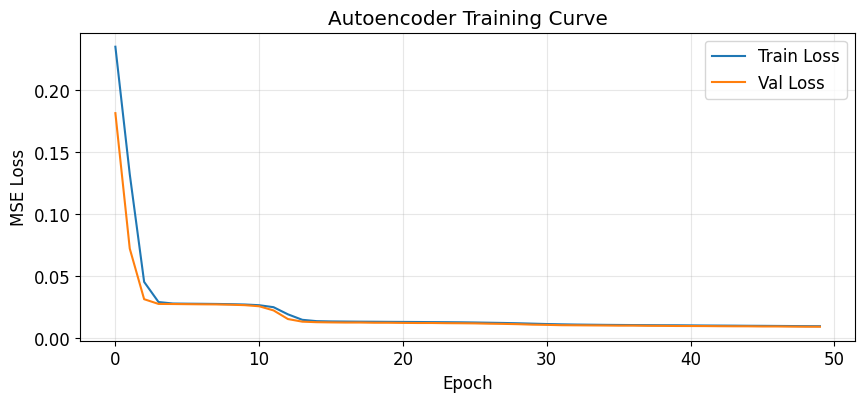

In [8]:
# 학습 곡선
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=1.5)
plt.plot(val_losses, label='Val Loss', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('h2_fig_ae_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 재구성 오차 분석 및 임계값 설정

Reconstruction Error Statistics:
  Healthy   - mean: 0.009364, std: 0.004265, 95%: 0.017621
  Degrading - mean: 0.021035, std: 0.034854, 95%: 0.072365

Threshold (95th percentile of healthy): 0.017621


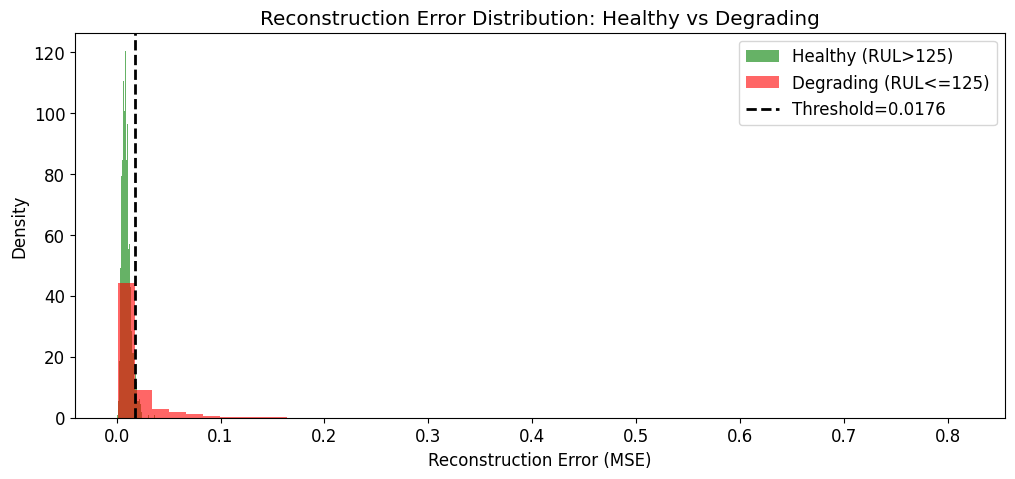

In [9]:
# 전체 데이터에 대한 재구성 오차 계산
model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_all).to(device)
    X_recon = model(X_tensor).cpu().numpy()

recon_errors = np.mean((X_all - X_recon) ** 2, axis=1)

# 정상/이상 그룹별 분포
healthy_errors = recon_errors[y_all == 1]
degrading_errors = recon_errors[y_all == 0]

print(f'Reconstruction Error Statistics:')
print(f'  Healthy   - mean: {healthy_errors.mean():.6f}, std: {healthy_errors.std():.6f}, 95%: {np.percentile(healthy_errors, 95):.6f}')
print(f'  Degrading - mean: {degrading_errors.mean():.6f}, std: {degrading_errors.std():.6f}, 95%: {np.percentile(degrading_errors, 95):.6f}')

# 임계값: 정상 데이터의 95퍼센타일
threshold = np.percentile(healthy_errors, 95)
print(f'\nThreshold (95th percentile of healthy): {threshold:.6f}')

plt.figure(figsize=(12, 5))
plt.hist(healthy_errors, bins=50, alpha=0.6, label='Healthy (RUL>125)', color='green', density=True)
plt.hist(degrading_errors, bins=50, alpha=0.6, label='Degrading (RUL<=125)', color='red', density=True)
plt.axvline(x=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution: Healthy vs Degrading')
plt.legend()
plt.savefig('h2_fig_recon_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 이상 탐지 성능 평가

In [10]:
# 이상 탐지 예측
y_pred = (recon_errors > threshold).astype(int)
y_true = 1 - y_all  # 1=anomaly(degrading), 0=normal(healthy)
y_pred_anomaly = y_pred  # 이미 recon_error > threshold면 anomaly

print('=== Autoencoder Anomaly Detection ===')
print(classification_report(y_true, y_pred_anomaly, target_names=['Healthy', 'Degrading']))

# ROC-AUC
auc = roc_auc_score(y_true, recon_errors)
print(f'ROC-AUC: {auc:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_anomaly)
print(f'\nConfusion Matrix:')
print(f'              Predicted')
print(f'              Healthy  Degrading')
print(f'Actual Healthy    {cm[0][0]:>5}     {cm[0][1]:>5}')
print(f'Actual Degrading  {cm[1][0]:>5}     {cm[1][1]:>5}')

=== Autoencoder Anomaly Detection ===
              precision    recall  f1-score   support

     Healthy       0.44      0.95      0.61      1563
   Degrading       0.90      0.29      0.44      2600

    accuracy                           0.54      4163
   macro avg       0.67      0.62      0.52      4163
weighted avg       0.73      0.54      0.50      4163

ROC-AUC: 0.6710

Confusion Matrix:
              Predicted
              Healthy  Degrading
Actual Healthy     1484        79
Actual Degrading   1852       748


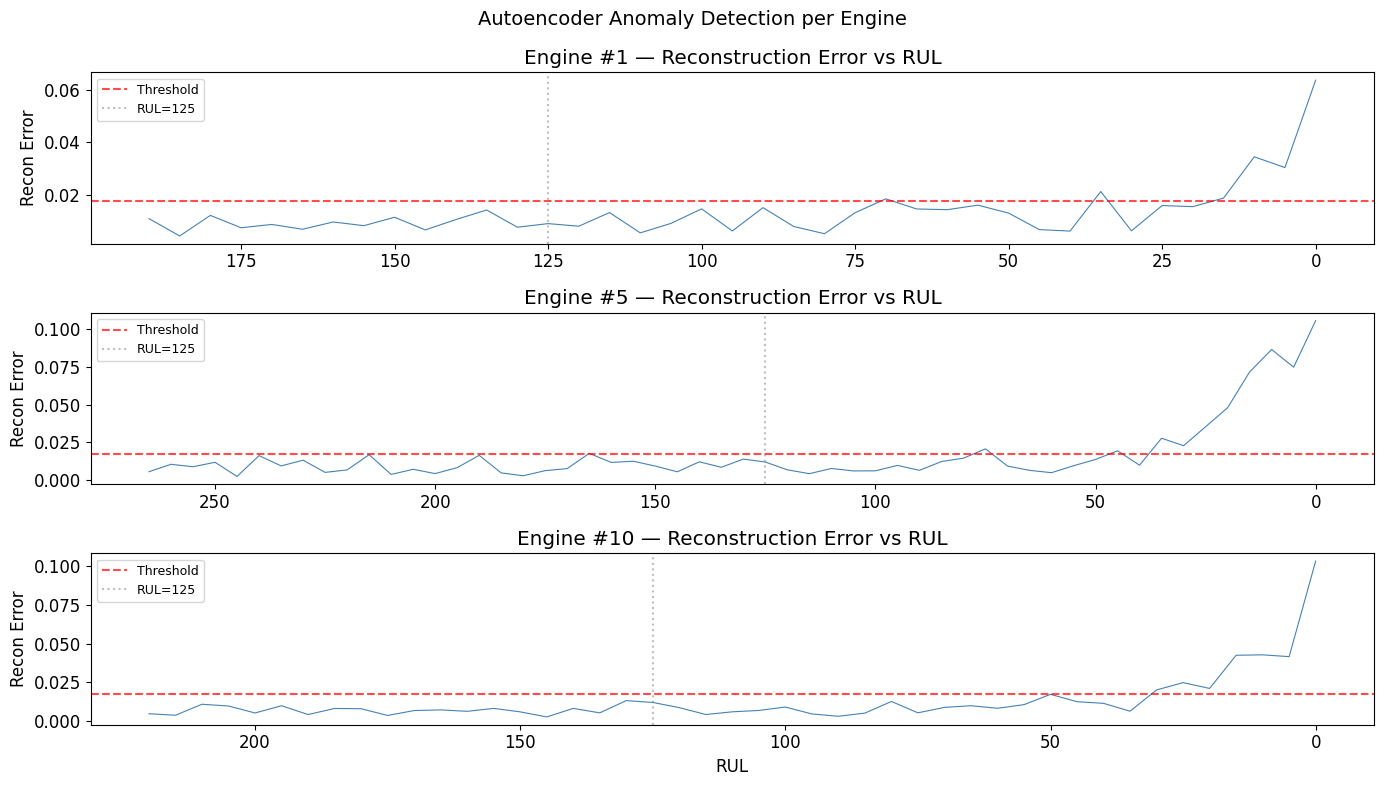


[관찰] RUL이 125 이하로 떨어지면 재구성 오차가 급격히 증가
[관찰] Autoencoder는 정상 패턴만 학습했기 때문에, 노화 패턴을 '이상'으로 감지


In [11]:
# 엔진별 노화 탐지 시점 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, engine_id in enumerate([1, 5, 10]):
    engine_data = train_df[train_df.unit == engine_id]
    engine_errors = recon_errors[train_df.unit == engine_id]
    engine_rul = engine_data['rul'].values
    
    axes[i].plot(engine_rul, engine_errors, linewidth=0.8, color='steelblue')
    axes[i].axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold')
    axes[i].axvline(x=125, color='gray', linestyle=':', alpha=0.5, label='RUL=125')
    axes[i].set_title(f'Engine #{engine_id} — Reconstruction Error vs RUL')
    axes[i].set_ylabel('Recon Error')
    axes[i].legend(fontsize=9)
    axes[i].invert_xaxis()

axes[-1].set_xlabel('RUL')
plt.suptitle('Autoencoder Anomaly Detection per Engine', fontsize=14)
plt.tight_layout()
plt.savefig('h2_fig_ae_per_engine.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] RUL이 125 이하로 떨어지면 재구성 오차가 급격히 증가")
print("[관찰] Autoencoder는 정상 패턴만 학습했기 때문에, 노화 패턴을 '이상'으로 감지")

## 8. Latent Space 시각화

Latent space shape: (4163, 8)


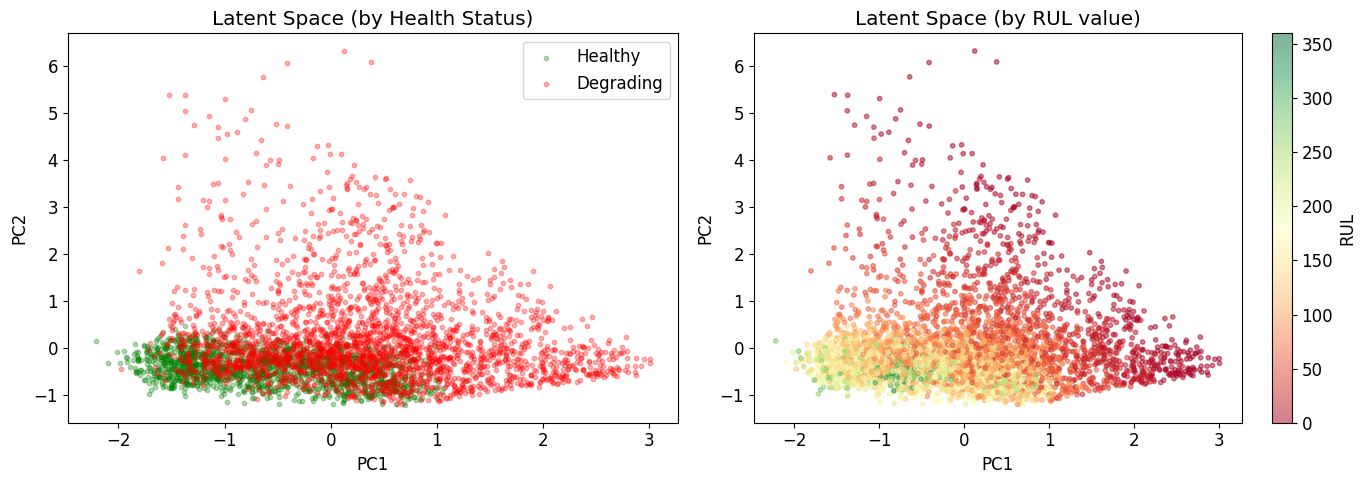


[관찰] Latent space에서 정상과 노화 데이터가 분리되는 패턴 확인
[관찰] RUL이 낮을수록(빨간색) latent space에서 멀어지는 경향


In [12]:
from sklearn.decomposition import PCA

# Latent representation 추출
model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_all).to(device)
    z = model.encoder(X_tensor).cpu().numpy()

print(f'Latent space shape: {z.shape}')

# 2D PCA로 시각화
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z)

# RUL에 따른 색상
rul_values = train_df['rul'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 건강 상태별
scatter = axes[0].scatter(z_2d[y_all==1, 0], z_2d[y_all==1, 1], c='green', alpha=0.3, s=10, label='Healthy')
scatter = axes[0].scatter(z_2d[y_all==0, 0], z_2d[y_all==0, 1], c='red', alpha=0.3, s=10, label='Degrading')
axes[0].set_title('Latent Space (by Health Status)')
axes[0].legend()

# RUL 값별
scatter = axes[1].scatter(z_2d[:, 0], z_2d[:, 1], c=rul_values, cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(scatter, ax=axes[1], label='RUL')
axes[1].set_title('Latent Space (by RUL value)')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('h2_fig_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[관찰] Latent space에서 정상과 노화 데이터가 분리되는 패턴 확인")
print("[관찰] RUL이 낮을수록(빨간색) latent space에서 멀어지는 경향")

## 9. 요약

### Autoencoder 이상 탐지 파이프라인
1. **전처리**: 14개 유효 센서 선택, MinMaxScaler 정규화
2. **학습**: 정상 구간(RUL>125) 데이터만으로 Autoencoder 학습
3. **임계값**: 정상 데이터 재구성 오차의 95th percentile
4. **탐지**: 재구성 오차 > 임계값 → 이상으로 판정

### 핵심 인사이트
- 정상 데이터만으로 학습해도 노화 패턴을 효과적으로 탐지
- 재구성 오차는 RUL이 낮아질수록 증가하는 명확한 패턴
- Latent space에서 건강/노화 상태의 분리가 시각적으로 확인 가능

### 교재 연결
- *Hands-On Unsupervised Learning* Ch.4: PCA 재구성 오차 기반 이상 탐지와 동일 원리
- 신용카드 사기 탐지에서 정상 거래로만 학습 → 이상 거래 탐지와 같은 접근